#***Scripts* introdutórios sobre Earth Foundation Models**

### Neste *notebook* vamos extrair *embeddings* de imagens de satélite usando o **DOFA**, um *foundation model* desenvolvido e pré-treinado para dados de observação da Terra. *Embeddings* são representações vetoriais aprendidas pelo modelo que transformam uma imagem em uma sequência de números, capturando diferentes características e padrões presentes na cena. No nosso *pipeline*, vamos agregar as representações geradas pelo modelo para obter um único vetor que represente cada imagem (vamos utilizar um subconjunto reduzido apenas para fins exemplificativos), em vez de produzir uma representação independente para cada pixel.

### Usaremos um *subset* do *dataset* **EuroSAT** (consulte em: https://github.com/phelber/eurosat), com 100 imagens para treino e 100 para validação, distribuídas em 10 classes de uso e cobertura da terra. Depois de extrair os *embeddings*, aplicaremos PCA (*Principal Component Analysis*) para reduzir sua dimensionalidade de 45 para apenas 2 dimensões, pois isso nos permitirá visualizar, em um gráfico 2D, como as diferentes classes se distribuem no espaço dos *embeddings*.

### Se imagens da mesma classe tenderem a formar agrupamentos e classes diferentes apresentarem maior separação, isso será um indício de que os *embeddings* capturaram características discriminativas relevantes das cenas. O TorchGEO (consulte em: https://github.com/torchgeo/torchgeo) será usado como base do nosso *pipeline* para trabalhar com os dados geoespaciais e o modelo.

##1. Primeiramente vamos baixar a biblioteca TorchGEO

In [14]:
!pip install torchgeo

Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/queues.py", line 257, in _feed
    reader_close()
    ~~~~~~~~~~~~^^
  File "/usr/lib/python3.13/multiprocessing/connection.py", line 183, in close
    self._close()
    ~~~~~~~~~~~^^
  File "/usr/lib/python3.13/multiprocessing/connection.py", line 382, in _close
    _close(self._handle)
    ~~~~~~^^^^^^^^^^^^^^
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.13/threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "/usr/lib/python3.13/threading.py", line 995, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.13/multiprocessing/queues.py", line 289, in _feed
    queue_sem.release()
    ~~~~~~~~~~~~~~~~~^^
ValueError: semaphore or lock released too ma

##2. Agora importaremos todas as bibliotecas que vamos usar

In [15]:
import torch  # Framework principal de deep learning - usado para processar tensores e rodar o modelo
import matplotlib.pyplot as plt  # Criação de gráficos - usado para visualizar os embeddings com PCA
import numpy as np  # Operações matemáticas com arrays - usado para manipular os embeddings (vetores)
from sklearn.decomposition import PCA  # Redução de dimensionalidade - usado para transformar dimensões em 2D para visualização
from torchgeo.datamodules import EuroSAT100DataModule  # Gerenciador de dados - usado para baixar e organizar o dataset EuroSAT-100 (https://docs.torchgeo.org/en/stable/api/datamodules.html)
from torchgeo.datasets import EuroSAT100  # Dataset específico - usado para baixar as imagens de satélite (https://github.com/torchgeo/torchgeo/blob/main/torchgeo/datamodules/eurosat.py)
from torchgeo.models import DOFABase16_Weights, get_model  # Modelo pré-treinado - usado para carregar o DOFA com pesos já treinados
from tqdm import tqdm  # Barra de progresso - usada para mostrar o andamento da extração de embeddings
import tempfile  # Arquivos temporários - usado para baixar o dataset em uma pasta temporária
import os  # Operações de sistema - usado para criar caminhos de pastas
from torchvision import transforms  # Transformações de imagem - usado para redimensionar as imagens para 224x224

##3. Configuramos o uso da GPU, se disponível

######**Dica**: No Google Colab, vá em Ambiente de Execucação > Alterar o tipo de ambiente de execucação > GPUs T4.

In [16]:
print("Configurando o ambiente...")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Usando dispositivo: {device}")

Configurando o ambiente...
Usando dispositivo: cuda


##4. Download do Dataset EuroSAT-100

######O EuroSAT-100 é uma versão reduzida do dataset EuroSAT com apenas 100 imagens por split (treino e validação). Ele contém 10 classes diferentes (floresta, rio, cidade, cultivo, etc.) e é ideal para experimentos rápidos porque é pequeno e fácil de baixar.

In [17]:
# Baixar um dataset pequeno de imagens de satélite (EuroSAT-100)
root = os.path.join(tempfile.gettempdir(), 'eurosat100')
print(f"Baixando dataset EuroSAT-100 em: {root}")
EuroSAT100(root=root, split='train', download=True)
EuroSAT100(root=root, split='val', download=True)


Baixando dataset EuroSAT-100 em: /tmp/eurosat100


Dataset EuroSAT100
    Number of datapoints: 20
    Root location: /tmp/eurosat100/ds/images/remote_sensing/otherDatasets/sentinel_2/tif

##5. Carregar o *foundation model* (DOFA) para geração dos *embeddings*

#####O DOFA (*Dynamic One-For-All*) é um *foundation model* treinado com imagens de satélite. Ele foi pré-treinado com a técnica MAE (*Masked Autoencoder*) para aprender representações do planeta Terra. O parâmetro 'dofa_base_patch16_224' indica a arquitetura do modelo, onde patch16 significa que a imagem é dividida em blocos de 16x16 pixels, e 224 é o tamanho da imagem de entrada.

In [18]:
# CARREGAR O MODELO (Foundation Model)
print("Carregando o modelo DOFA (pré-treinado)...")
model = get_model('dofa_base_patch16_224', weights=DOFABase16_Weights.DOFA_MAE)
model = model.eval().to(device)

Carregando o modelo DOFA (pré-treinado)...


##6. Extração de *embeddings*

#####A função recebe o modelo, um dataloader com imagens e o dispositivo (CPU/GPU). Para cada imagem, ela redimensiona para 224x224 (tamanho esperado pelo DOFA) e passa pelo modelo junto com os comprimentos de onda das bandas RGB (490nm para azul, 560nm para verde, 665nm para vermelho). O DOFA é flexível e aceita diferentes combinações de bandas espectrais. O resultado é um vetor numérico que representa a "essência" da imagem.

In [19]:
# FUNÇÃO PARA EXTRAIR EMBEDDINGS (CORRIGIDA - VERSÃO 2)
def extrair_embeddings(model, dataloader, device):
    """Extrai embeddings de um dataloader usando o modelo DOFA."""
    todos_embeddings = []
    todos_rotulos = []

    # Comprimentos de onda para as bandas B02, B03, B04 (em nanômetros)
    wavelengths = torch.tensor([490, 560, 665]).float().to(device)

    # Transform para redimensionar para 224x224 (tamanho que o DOFA espera)
    resize = transforms.Resize((224, 224))

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Extraindo embeddings"):
            imagens = batch['image'].to(device)

            # Redimensionar para 224x224
            imagens = resize(imagens)

            # DOFA espera: (imagem, wavelengths)
            embeddings = model(imagens, wavelengths).cpu().numpy()
            todos_embeddings.append(embeddings)
            todos_rotulos.append(batch['label'].numpy())

    return np.concatenate(todos_embeddings), np.concatenate(todos_rotulos)

# 5. PREPARAR OS DADOS E EXTRAIR EMBEDDINGS
print("Preparando os DataLoaders...")
datamodule = EuroSAT100DataModule(
    root=root, batch_size=32, num_workers=2, bands=('B02', 'B03', 'B04') # apenas 32 imagens no nosso exemplo
)
datamodule.setup('fit')
train_dl = datamodule.train_dataloader()

print("Extraindo embeddings das imagens de treino...")
embeddings, rotulos = extrair_embeddings(model, train_dl, device)
print(f"{len(embeddings)} embeddings extraídos! Cada um com {embeddings.shape[1]} dimensões.")

Preparando os DataLoaders...
Extraindo embeddings das imagens de treino...


Extraindo embeddings: 100%|██████████| 1/1 [00:00<00:00,  1.31it/s]

32 embeddings extraídos! Cada um com 45 dimensões.


##7. Projetar *embeddings* em 2D com PCA para análise de agrupamento

##### PCA (*Principal Component Analysis*) é uma técnica matemática que reduz a dimensionalidade dos dados. Cada *embedding* original tem 45 dimensões (números). O PCA encontra as duas direções mais importantes (chamadas de Componentes Principais) que preservam a maior parte das diferenças entre os *embeddings*. Cada imagem vira um ponto no gráfico 2D. As cores indicam a classe real da imagem. Se o modelo for bom, pontos da mesma classe aparecerão próximos, formando agrupamentos distintos.

Reduzindo dimensionalidade com PCA para visualização...
Plotando os embeddings...


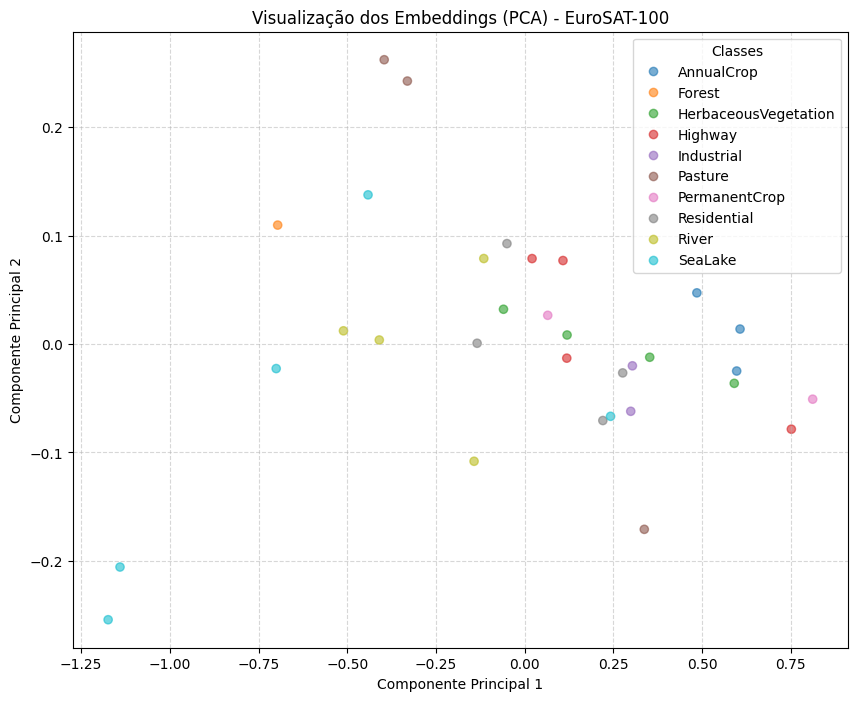

In [20]:
# VISUALIZAR OS EMBEDDINGS COM PCA
print("Reduzindo dimensionalidade com PCA para visualização...")
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Nomes das classes do EuroSAT para o gráfico
nomes_classes = [
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial',
    'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake'
]

print("Plotando os embeddings...")
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=rotulos, cmap='tab10', alpha=0.6)
plt.legend(handles=scatter.legend_elements()[0], labels=nomes_classes, title="Classes")
plt.title("Visualização dos Embeddings (PCA) - EuroSAT-100")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True, linestyle='--', alpha=0.5)

## **Análise dos resultados**

A visualização dos *embeddings* após a aplicação do PCA mostra que as 10 classes do EuroSAT-100 apresentam **algum grau de organização no espaço vetorial**, mas não formam grupos completamente separados (convenhamos que é esperado quando usamos apenas as bandas RGB). Há regiões com maior concentração de determinadas classes, enquanto outras apresentam bastante sobreposição.

É importante lembrar que o PCA reduziu os *embeddings* de **45 para apenas 2 dimensões**. Portanto, estamos observando somente uma projeção de um espaço muito maior. A proximidade entre dois pontos no gráfico não significa necessariamente que suas representações sejam próximas no espaço original, assim como a sobreposição entre classes não significa que o modelo seja incapaz de diferenciá-las...

Também podemos observar que algumas classes apresentam características que parecem ser compartilhadas por outras. Por exemplo, categorias como *Industrial* e *Residential* podem apresentar padrões visuais semelhantes, enquanto *Forest*, *HerbaceousVegetation* e *AnnualCrop* também podem compartilhar características relacionadas à cobertura do solo. Em imagens de satélite, essas fronteiras podem ser naturalmente difíceis de definir, já que uma mesma cena pode conter diferentes tipos de cobertura e estruturas.

Assim, este resultado deve ser interpretado como uma **visualização exploratória dos *embeddings*** (até porque utilizamos um conjunto pequeno de dados), e não como uma avaliação definitiva da qualidade do DOFA. O fato de existir sobreposição no gráfico 2D não significa que a informação discriminativa não esteja presente nas 45 dimensões originais. O objetivo desse Notebook foi mostrar, na prática, uma aplicação **extremamente simples** de um *foundation model*, *embeddings* e do TorchGEO.

## **O que vimos?**

Este exercício mostra uma ideia importante sobre *embeddings*: eles transformam dados complexos em representações numéricas que podem ser analisadas matematicamente. O PCA nos permite visualizar parte dessa estrutura, mas também evidencia que reduzir um espaço de alta dimensão para apenas duas dimensões pode esconder informações importantes. Portanto, o próximo passo para avaliar os *embeddings* de forma mais rigorosa seria utilizar métricas quantitativas ou uma tarefa downstream, como classificação, *clustering* ou avaliação de similaridade (que é o que trabalhos científicos sérios fazem com dados do mundo real: tentam resolver problemas).

<small>O DeepSeek foi utilizado na padronização dos códigos.</small>

**Bio**

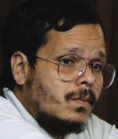

Alisson de Oliveira é Bacharel em Gestão e Análise Ambiental pela Universidade Federal de São Carlos (UFSCar) desde 2021 e Mestre em Sensoriamento Remoto pelo Instituto Nacional de Pesquisas Espaciais (INPE) desde 2024. Atualmente está no terceiro ano do doutorando em Sensoriamento Remoto no INPE, onde desenvolve pesquisas voltadas à análise ambiental utilizando dados de sensoriamento remoto e *machine learning*, como foco na utilização dos satélites brasileiros CBERS-4, CBERS-4A e AMAZONIA-1